<a href="https://colab.research.google.com/github/RinadOsama12/ID_verification_22_NTI_CV_Project/blob/main/ID_Card_Region_Detection_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python -q
!pip install opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 12.9 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 7.9 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("nour-ragab").project("lozy-merged-ov8uw")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lozy-Merged--1 in yolov8:: 100%|██████████| 1601/1601 [00:00<00:00, 2413.48it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
import os, shutil, random

base = "Lozy-Merged--1"
combined_img = f"{base}/all_images"
combined_lbl = f"{base}/all_labels"
os.makedirs(combined_img, exist_ok=True)
os.makedirs(combined_lbl, exist_ok=True)

for split in ["train", "valid", "test"]:
    img_dir = f"{base}/{split}/images"
    lbl_dir = f"{base}/{split}/labels"
    if os.path.exists(img_dir):
        for f in os.listdir(img_dir):
            shutil.copy(os.path.join(img_dir, f), os.path.join(combined_img, f))
    if os.path.exists(lbl_dir):
        for f in os.listdir(lbl_dir):
            shutil.copy(os.path.join(lbl_dir, f), os.path.join(combined_lbl, f))

print("Total images:", len(os.listdir(combined_img)))
print("Total labels:", len(os.listdir(combined_lbl)))

Total images: 798
Total labels: 798


In [ ]:
import os, shutil, random

base = "Lozy-Merged--1"
combined_img = f"{base}/all_images"
combined_lbl = f"{base}/all_labels"

all_files = [f for f in os.listdir(combined_img)]
random.seed(42)
random.shuffle(all_files)

n = len(all_files)
n_train = int(n * 0.8)
n_valid = int(n * 0.1)

splits = {
    "train": all_files[:n_train],
    "valid": all_files[n_train:n_train + n_valid],
    "test": all_files[n_train + n_valid:]
}

for split in ["train", "valid", "test"]:
    img_out = f"{base}/{split}/images"
    lbl_out = f"{base}/{split}/labels"
    shutil.rmtree(img_out, ignore_errors=True)
    shutil.rmtree(lbl_out, ignore_errors=True)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for img_file in splits[split]:
        label_file = os.path.splitext(img_file)[0] + ".txt"
        shutil.copy(os.path.join(combined_img, img_file), os.path.join(img_out, img_file))
        label_path = os.path.join(combined_lbl, label_file)
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(lbl_out, label_file))

for split in ["train", "valid", "test"]:
    print(split, ":", len(os.listdir(f"{base}/{split}/images")), "images")

train : 638 images
valid : 79 images
test : 81 images


In [ ]:
print(open("Lozy-Merged--1/data.yaml").read())

names:
- Add1
- Add2
- Face
- Name
- Name1
- Name2
- Num1
- Num2
nc: 8
roboflow:
  license: CC BY 4.0
  project: lozy-merged-ov8uw
  url: https://universe.roboflow.com/nour-ragab/lozy-merged-ov8uw/dataset/1
  version: 1
  workspace: nour-ragab
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="Lozy-Merged--1/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    patience=15,
    project="id_detection",
    name="yolov8n_run1"
)

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Lozy-Merged--1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_run1, nbs=64, nms=None, opset=None, optimize

Lozy-Merged--1/test/images/6a0c3a9b-12e8-4472-b46d-320b5fc50b23_png.rf.3783aa22dba3c343a25b8358654b1492.jpg

image 1/1 /content/Lozy-Merged--1/test/images/6a0c3a9b-12e8-4472-b46d-320b5fc50b23_png.rf.3783aa22dba3c343a25b8358654b1492.jpg: 288x416 1 Add1, 1 Add2, 1 Face, 1 Name1, 1 Name2, 1 Num1, 1 Num2, 6.1ms
Speed: 1.0ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 416)
Results saved to /content/runs/detect/predict-8


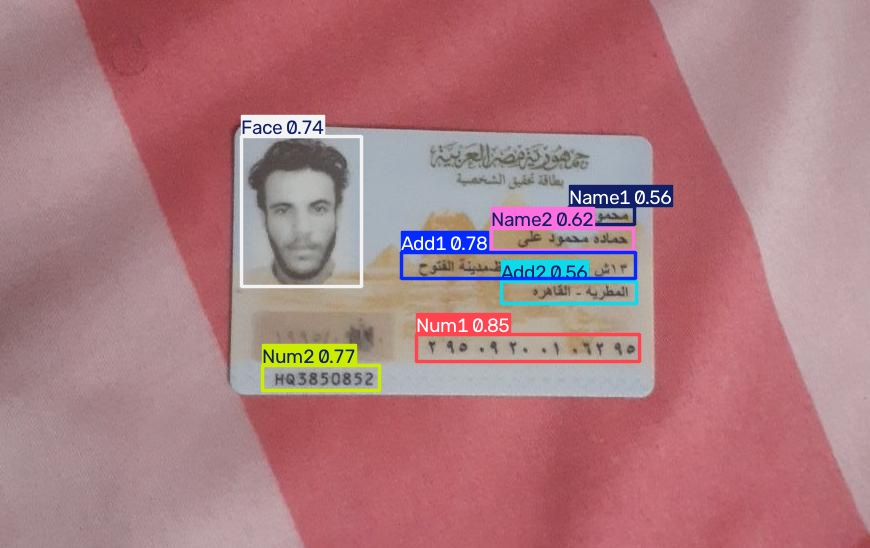

In [ ]:
import glob, random
from ultralytics import YOLO

model = YOLO("/content/runs/detect/id_detection/yolov8n_run1/weights/best.pt")

test_images = glob.glob("Lozy-Merged--1/test/images/*")
random_img_path = random.choice(test_images)
print(random_img_path)

result = model.predict(random_img_path, save=True, conf=0.5)

from PIL import Image
Image.open(result[0].save_dir + "/" + random_img_path.split("/")[-1])

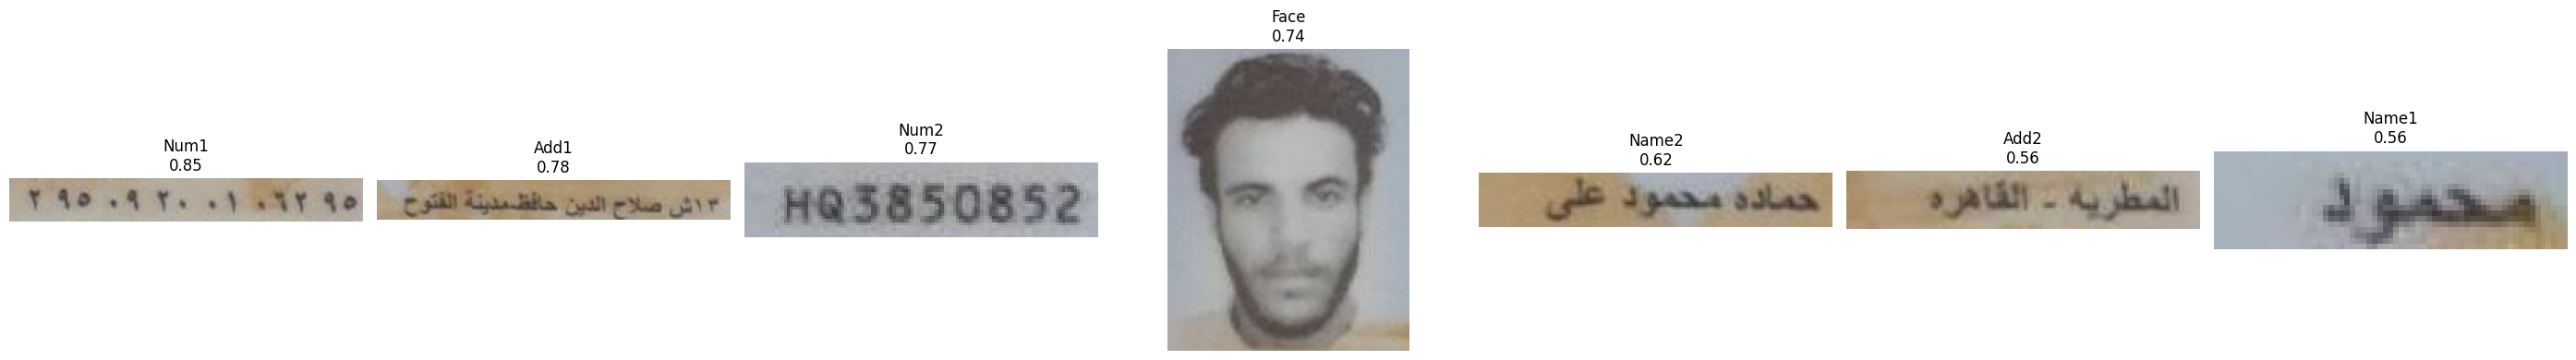

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_each_class_separately(image_path, conf=0.5):
    img = Image.open(image_path)
    results = model.predict(image_path, conf=conf, verbose=False)
    boxes = results[0].boxes
    names = results[0].names

    n = len(boxes)
    if n == 0:
        print("There is no face")
        return

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for i, box in enumerate(boxes):
        cls_id = int(box.cls[0])
        cls_name = names[cls_id]
        conf_val = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = img.crop((x1, y1, x2, y2))

        axes[i].imshow(crop)
        axes[i].set_title(f"{cls_name}\n{conf_val:.2f}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_each_class_separately(random_img_path)

Saving images.jpg to images.jpg
Uploaded and renamed to: uploaded_id.jpg

image 1/1 /content/uploaded_id.jpg: 256x416 3 Add1s, 1 Add2, 1 Face, 1 Name1, 1 Name2, 1 Num1, 1 Num2, 7.0ms
Speed: 1.3ms preprocess, 7.0ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 416)
Results saved to /content/runs/detect/predict-9


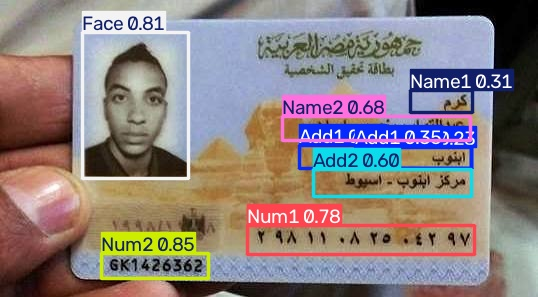

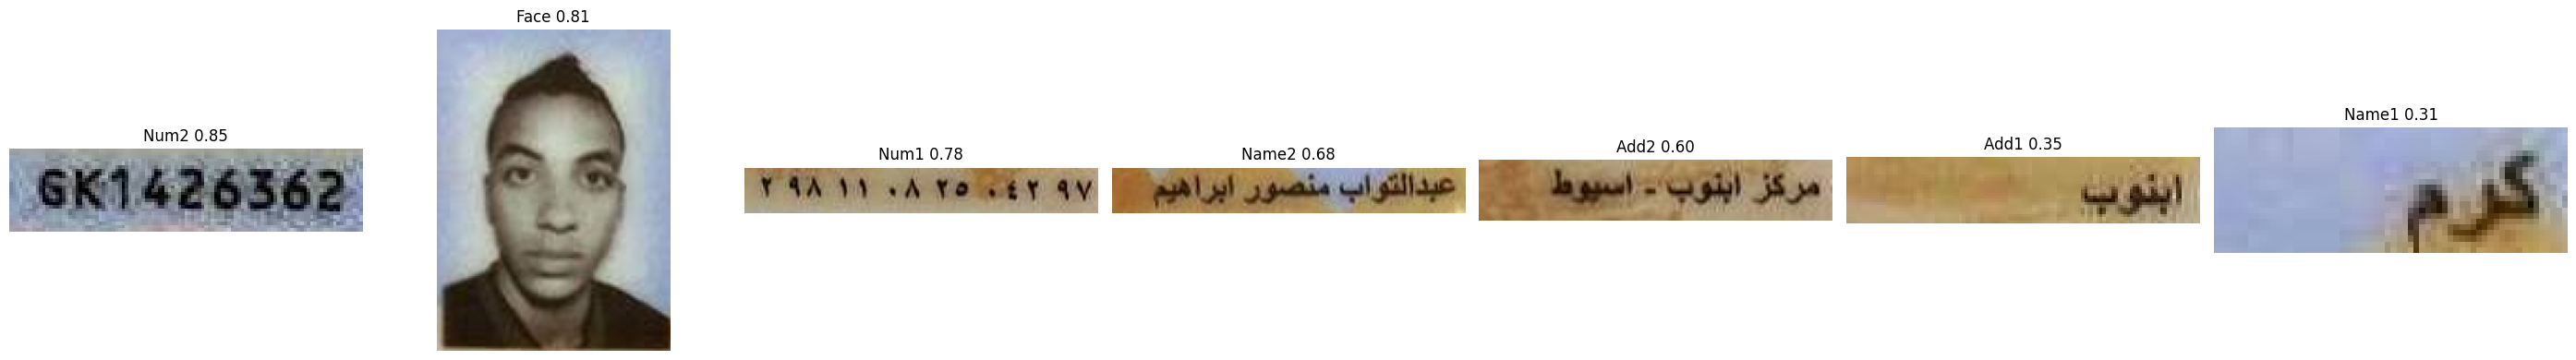

In [ ]:
from google.colab import files
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import shutil

uploaded = files.upload()
original_name = list(uploaded.keys())[0]
image_path = "uploaded_id.jpg"
shutil.copy(original_name, image_path)
print("Uploaded and renamed to:", image_path)

model = YOLO("/content/runs/detect/id_detection/yolov8n_run1/weights/best.pt")

result = model.predict(image_path, save=True, conf=0.15)
img_with_boxes = Image.open(result[0].save_dir + "/" + image_path)
display(img_with_boxes)

img = Image.open(image_path)
results = model.predict(image_path, conf=0.15, verbose=False)
boxes = results[0].boxes
names = results[0].names

best_boxes = {}
for box in boxes:
    cls_id = int(box.cls[0])
    cls_name = names[cls_id]
    conf_val = float(box.conf[0])
    if cls_name not in best_boxes or conf_val > best_boxes[cls_name][1]:
        best_boxes[cls_name] = (box, conf_val)

n = len(best_boxes)
if n == 0:
    print("No fields detected in this image")
else:
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for i, (cls_name, (box, conf_val)) in enumerate(best_boxes.items()):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = img.crop((x1, y1, x2, y2))
        axes[i].imshow(crop)
        axes[i].set_title(f"{cls_name} {conf_val:.2f}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()